### Naive doest works the best when the feature are correlated it works well when the features are independent used in classfication problems 
### Logistic is better in this case 

In [90]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix 


In [91]:
cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

x.shape,y.shape

((569, 30), (569,))

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((455, 30), (114, 30), (455,), (114,))

In [93]:
x_train


array([[9.029e+00, 1.733e+01, 5.879e+01, ..., 1.750e-01, 4.228e-01,
        1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, ..., 2.903e-01, 4.098e-01,
        1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, ..., 5.087e-02, 3.282e-01,
        8.490e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]], shape=(455, 30))

In [94]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [95]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [96]:
lor = LogisticRegression(max_iter = 3000)
nb = GaussianNB()

In [97]:
lor.fit(x_train_scaled,y_train)
y_pred_lor = lor.predict(x_test_scaled)
print(accuracy_score(y_pred_lor, y_test))

0.9736842105263158


In [98]:
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
print(accuracy_score(y_pred_nb, y_test))

0.9736842105263158


In [99]:
nb.class_count_

array([169., 286.])

In [100]:
print("LOR Confusion matrix")
print(confusion_matrix(y_test,y_pred_lor))

LOR Confusion matrix
[[41  2]
 [ 1 70]]


In [101]:
print("NB Confusion matrix")
print(confusion_matrix(y_test,y_pred_nb))

NB Confusion matrix
[[40  3]
 [ 0 71]]


In [102]:
lor_proba = lor.predict_proba(x_test_scaled)
print(lor.predict_proba(x_test_scaled))

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]
 [1.00000000e+00 9.48087773e-11]
 [9.99999998e-01 1.53672648e-09]
 [9.65096937e-01 3.49030633e-02]
 [3.79342140e-01 6.20657860e-01]
 [7.59402734e-04 9.99240597e-01]
 [4.98717826e-02 9.50128217e-01]
 [9.87592879e-01 1.24071210e-02]
 [6.07381873e-03 9.93926181e-01]
 [8.56069117e-01 1.43930883e-01]
 [1.62175599e-03 9.98378244e-01]
 [9.99259818e-01 7.40182295e-04]
 [1.85245908e-03 9.98147541e-01]
 [1.11662359e-05 9.99988834e-01]
 [8.18375684e-07 9.99999182e-01]
 [9.99998883e-01 1.11701472e-06]
 [8.41633901e-02 9.15836610e-01]
 [9.74778299e-03 9.90252217e-01]
 [9.99999996e-01 4.33732393e-09]
 [7.89186669e-05 9.99921081e-01]
 [1.13874333e-03 9.98861257e-01]
 [5.84587240e-04 9.99415413e-01]
 [1.07444521e-03 9.98925555e-01]
 [5.97518345e-03 9.94024817e-01]
 [2.85311713e-03 9.97146883e-01]
 [9.99991817e-01 8.18296669e-06]
 [5.174098

In [103]:
nb_proba  = nb.predict_proba(x_test_scaled)
print(nb.predict_proba(x_test))

[[2.42625723e-009 9.99999998e-001]
 [1.00000000e+000 1.08688415e-058]
 [9.99999999e-001 6.07872900e-010]
 [1.50822001e-011 1.00000000e+000]
 [2.03620972e-014 1.00000000e+000]
 [1.00000000e+000 7.65734452e-103]
 [1.00000000e+000 1.30231106e-130]
 [1.00000000e+000 2.87673553e-019]
 [2.15664058e-001 7.84335942e-001]
 [3.97021560e-013 1.00000000e+000]
 [1.69029976e-012 1.00000000e+000]
 [1.00000000e+000 2.40158414e-017]
 [5.42353495e-011 1.00000000e+000]
 [1.00000000e+000 4.39892388e-010]
 [1.18731014e-013 1.00000000e+000]
 [1.00000000e+000 1.63244789e-039]
 [4.70465884e-012 1.00000000e+000]
 [3.85173933e-017 1.00000000e+000]
 [1.88797270e-014 1.00000000e+000]
 [1.00000000e+000 4.61157543e-066]
 [7.06421053e-006 9.99992936e-001]
 [2.73690627e-013 1.00000000e+000]
 [1.00000000e+000 2.42965079e-088]
 [1.13107773e-016 1.00000000e+000]
 [8.38503086e-015 1.00000000e+000]
 [2.74948747e-011 1.00000000e+000]
 [1.10843489e-012 1.00000000e+000]
 [2.64053061e-012 1.00000000e+000]
 [1.38567487e-013 1.

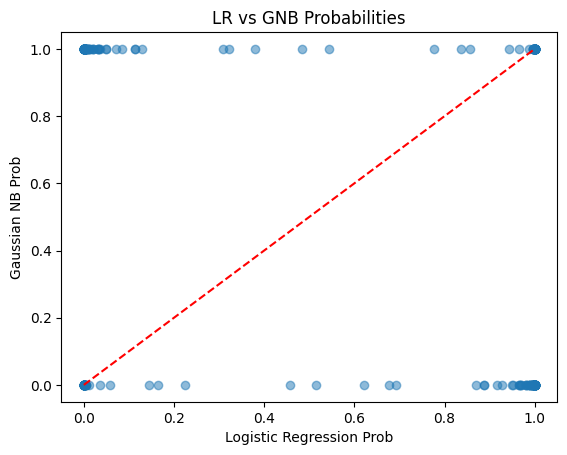

In [104]:
import matplotlib.pyplot as plt

plt.scatter(lor_proba, nb_proba, alpha=0.5)

plt.xlabel("Logistic Regression Prob")
plt.ylabel("Gaussian NB Prob")
plt.title("LR vs GNB Probabilities")

plt.plot([0,1], [0,1], 'r--')  # diagonal line
plt.show()

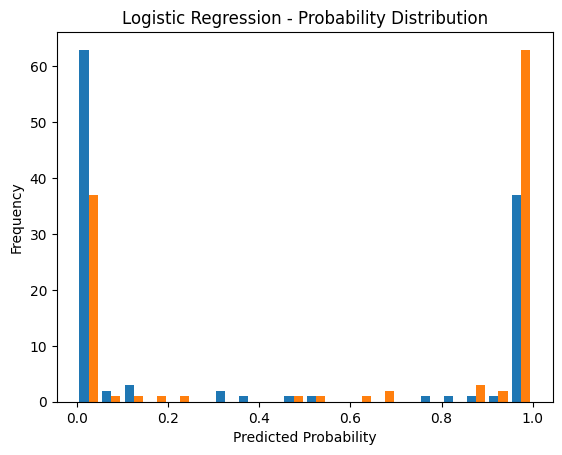

In [105]:
plt.hist(lor_proba, bins=20)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Logistic Regression - Probability Distribution")
plt.show()

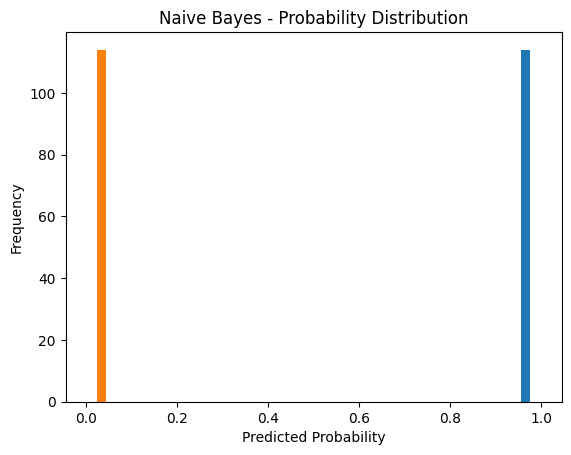

In [106]:
plt.hist(nb_proba, bins=20)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Naive Bayes - Probability Distribution")
plt.show()

In [113]:
lor_proba.shape, y_test.shape

((114, 2), (114,))

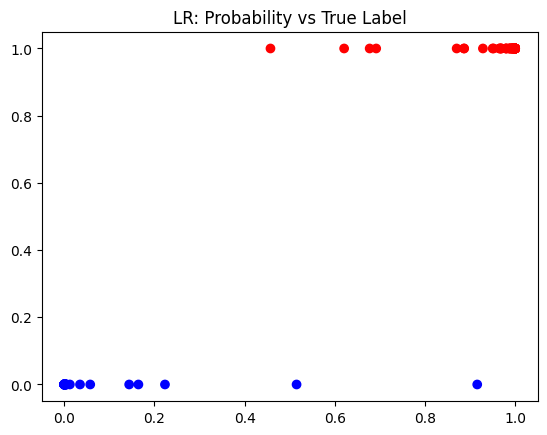

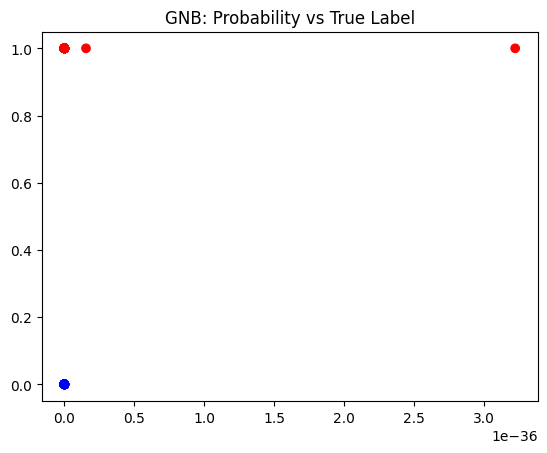

In [121]:
import numpy as np 
colors = np.where(y_test == 1, 'red', 'blue')
plt.scatter(lor_proba[:,1], y_test, c =colors )
plt.title("LR: Probability vs True Label")
plt.show()

plt.scatter(nb_proba[:,1], y_test, c =colors)
plt.title("GNB: Probability vs True Label")
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc

roc_curve(y_pred_lor, y_test)


(array([0.        , 0.02380952, 1.        ]),
 array([0.        , 0.97222222, 1.        ]),
 array([inf,  1.,  0.]))

In [124]:
roc_curve(y_pred_nb,y_test)

(array([0., 0., 1.]),
 array([0.        , 0.95945946, 1.        ]),
 array([inf,  1.,  0.]))

# What is a Calibration Curve?

It checks:

“When model says 0.8 probability… is it actually correct ~80% of the time?”

Perfect calibration = diagonal line

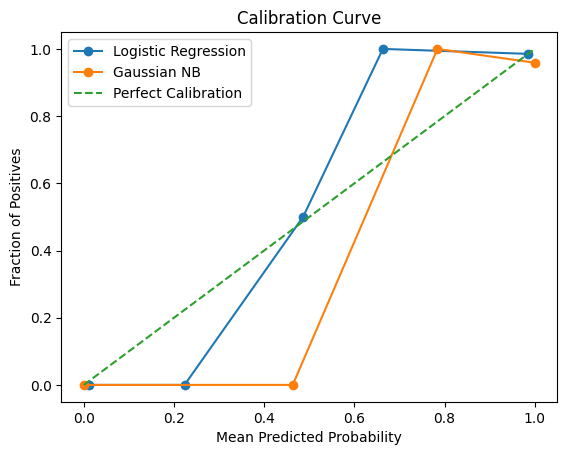

In [132]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ALWAYS start from original model output
lor_probs = lor.predict_proba(x_test_scaled)[:, 1]
nb_probs = nb.predict_proba(x_test)[:, 1]

# Compute calibration curves
lr_true, lr_pred = calibration_curve(y_test, lor_probs, n_bins=5)
gnb_true, gnb_pred = calibration_curve(y_test, nb_probs, n_bins=5)

# Plot
plt.plot(lr_pred, lr_true, marker='o', label='Logistic Regression')
plt.plot(gnb_pred, gnb_true, marker='o', label='Gaussian NB')

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [133]:
from sklearn.metrics import log_loss, brier_score_loss

print("LR Log Loss:", log_loss(y_test, lor_probs))
print("NB Log Loss:", log_loss(y_test, nb_probs))

print("LR Brier Score:", brier_score_loss(y_test, lor_probs))
print("NB Brier Score:", brier_score_loss(y_test, nb_probs))

LR Log Loss: 0.0601295506064487
NB Log Loss: 0.20373427152124873
LR Brier Score: 0.01670309396517733
NB Brier Score: 0.02835334345416164
